# 05 — Benchmark Comparison + Reliability (13 September 2026)
**Initial controlled benchmark between three mapping strategies on the SAME real nuScenes frames.**
Not a final system; not production-ready; no generalization claimed beyond the tested subset.

```text
                    SAME REAL FRAME
                          |
         +----------------+----------------+
         v                v                v
     PROPOSED        BASELINE 1        BASELINE 2
   Adaptive 2.5D     Uniform 5 cm    Distance adaptive
         |                |                |
         +----------------+----------------+
                          v
                  COMMON EVALUATION
```
Fairness rule: same frame, same coordinates, same preprocessing, same ROI, same source LiDAR,
same evaluation area, same metrics. ONLY the resolution strategy differs. Configurations are
frozen before the benchmark run (see `results/benchmark/benchmark_config.json`).

## 1. Environment and project setup

In [1]:
import sys
import os
import time
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.4.4
Pandas: 3.0.2


## 2. Project roots (Colab Drive mount with local fallback — same convention as notebook 04)

In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/LiDAR_Hackathon"
except ImportError:
    _cwd = os.path.abspath(os.getcwd())
    if os.path.isdir(os.path.join(_cwd, "src")) and os.path.isdir(os.path.join(_cwd, "data", "processed")):
        PROJECT_ROOT = _cwd
    else:
        PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))
    print("Local PROJECT_ROOT:", PROJECT_ROOT)

SRC_ROOT = os.path.join(PROJECT_ROOT, "src")
PROCESSED_ROOT = os.path.join(PROJECT_ROOT, "data", "processed")
RESULTS_ROOT = os.path.join(PROJECT_ROOT, "results")
BENCHMARK_ROOT = os.path.join(RESULTS_ROOT, "benchmark")
FIGURES_ROOT = os.path.join(BENCHMARK_ROOT, "figures")
NUSC_ROOT = os.path.join(PROJECT_ROOT, "data", "raw", "nuscenes")

os.makedirs(BENCHMARK_ROOT, exist_ok=True)
os.makedirs(FIGURES_ROOT, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("BENCHMARK_ROOT:", BENCHMARK_ROOT)

Local PROJECT_ROOT: c:\Users\SARKAR\Documents\Default Project
PROJECT_ROOT: c:\Users\SARKAR\Documents\Default Project
BENCHMARK_ROOT: c:\Users\SARKAR\Documents\Default Project\results\benchmark


## 3. Import existing modules (9–12 September work reused unchanged — no duplicates)

In [3]:
# Notebook-04 convention: both SRC_ROOT and PROJECT_ROOT on sys.path,
# imports as `from src.<module> import ...` so package-relative imports resolve.
if SRC_ROOT not in sys.path:
    sys.path.append(SRC_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.data_types import LiDARFrame, PerceptionResult, RegionFeatures
from src.interface_validator import validate_region_features
from src.preprocessing import preprocess_points, ROI_X, ROI_Y, ROI_Z
from src.importance_engine import ImportanceEngine
from src.resolution_engine import ResolutionEngine
from src.semantic_adapter import (aggregate_to_regions, annotations_to_sensor_frame,
    assign_annotation_semantics, build_perception_from_semantics)
from src.mapper_2_5d import build_adaptive_map, validate_adaptive_map_df
from src.baselines import (UNIFORM_RESOLUTION, DISTANCE_THRESHOLDS, build_distance_adaptive_map,
    build_uniform_map, distance_based_resolution, evaluation_area_from_regions,
    resolution_density_proxy)

importance_engine = ImportanceEngine()  # default repo config, unchanged
resolution_engine = ResolutionEngine()  # default repo config, unchanged
print("Imports OK — engines on default repo configuration.")

Imports OK — engines on default repo configuration.


## 4. Freeze benchmark configuration (before any benchmark execution)

In [4]:
import json
from config.importance_config import WEIGHTS, MAX_DISTANCE, UNCERTAINTY_LAMBDA
from config.resolution_config import RESOLUTION_LEVELS
import matplotlib

CELL_SIZE = 2.0  # frozen integration grid (repo convention, same as notebooks 03/04)
benchmark_config = {
    "task": "13 September 2026 initial benchmark subset (Paradox Protocol)",
    "cell_size_integration_m": CELL_SIZE,
    "roi": {"x": list(ROI_X), "y": list(ROI_Y), "z": list(ROI_Z)},
    "importance_weights": {k: float(v) for k, v in WEIGHTS.items()},
    "max_distance_m": float(MAX_DISTANCE),
    "uncertainty_lambda": float(UNCERTAINTY_LAMBDA),
    "proposed_resolution_levels": [[float(t), float(r)] for t, r in RESOLUTION_LEVELS],
    "uniform_resolution_m": float(UNIFORM_RESOLUTION),
    "distance_thresholds": [[float(u), float(r)] for u, r in DISTANCE_THRESHOLDS],
    "semantic_class_mapping": "src.semantic_mapping.map_nuscenes_label_to_project",
    "uncertainty_behavior": "documented fallback 0.5 for non-model regions",
    "software": {"python": sys.version.split()[0], "numpy": np.__version__,
                 "pandas": pd.__version__, "matplotlib": matplotlib.__version__},
}
with open(os.path.join(BENCHMARK_ROOT, "benchmark_config.json"), "w") as f:
    json.dump(benchmark_config, f, indent=2)
print(json.dumps(benchmark_config, indent=2))
print("Configuration frozen — no tuning after this point.")

{
  "task": "13 September 2026 initial benchmark subset (Paradox Protocol)",
  "cell_size_integration_m": 2.0,
  "roi": {
    "x": [
      -80.0,
      80.0
    ],
    "y": [
      -80.0,
      80.0
    ],
    "z": [
      -10.0,
      15.0
    ]
  },
  "importance_weights": {
    "distance": 0.3,
    "semantic": 0.3,
    "terrain": 0.15,
    "dynamic": 0.15,
    "uncertainty": 0.1
  },
  "max_distance_m": 100.0,
  "uncertainty_lambda": 0.15,
  "proposed_resolution_levels": [
    [
      0.75,
      0.05
    ],
    [
      0.5,
      0.1
    ],
    [
      0.25,
      0.2
    ],
    [
      0.0,
      0.5
    ]
  ],
  "uniform_resolution_m": 0.05,
  "distance_thresholds": [
    [
      10.0,
      0.05
    ],
    [
      30.0,
      0.1
    ],
    [
      60.0,
      0.2
    ],
    [
      Infinity,
      0.5
    ]
  ],
  "semantic_class_mapping": "src.semantic_mapping.map_nuscenes_label_to_project",
  "uncertainty_behavior": "documented fallback 0.5 for non-model regions",
  "software

## 5. Select benchmark frames (initial subset — not claimed representative of all nuScenes)

In [5]:
processed_files = sorted([f for f in os.listdir(PROCESSED_ROOT) if f.endswith("_LIDAR_TOP_xyzi.npy")])
print("Available processed frames:", len(processed_files))
benchmark_files = processed_files[:10]
print("Selected benchmark frames:", len(benchmark_files))
print(benchmark_files)

Available processed frames: 404
Selected benchmark frames: 10
['00889f8a9549450aa2f32cf310a3e305_LIDAR_TOP_xyzi.npy', '0106a9b8e65f4ad1867b44591aeed8b0_LIDAR_TOP_xyzi.npy', '023c4df2d451409881d8e6ea82f14704_LIDAR_TOP_xyzi.npy', '0307afa1ec7e48ce90295acabf8cb6dd_LIDAR_TOP_xyzi.npy', '0373e9d8886648779c8a73304919ab5f_LIDAR_TOP_xyzi.npy', '0402e40724984f3b833496067d46c771_LIDAR_TOP_xyzi.npy', '042f582eb2bb4231910918ba85f390d3_LIDAR_TOP_xyzi.npy', '048a45dd2cf54aa5808d8ccc85731d44_LIDAR_TOP_xyzi.npy', '050b2d9c4bb647b7ab4ee94bdb538e1d_LIDAR_TOP_xyzi.npy', '056becbc0d5a46da8d59eebddedb47bb_LIDAR_TOP_xyzi.npy']


## 6. Scene categories (Rajashree — from real scene/annotation metadata, documented rule)

In [6]:
from nuscenes.nuscenes import NuScenes
nusc = NuScenes(version="v1.0-mini", dataroot=NUSC_ROOT, verbose=False)
# Documented rule, applied in order: n_anns>=40 -> object-rich; "parking lot" -> mixed;
# "intersection"/"crosswalk"/"road" in scene description -> urban/road; "night" -> mixed; else mixed.
# "open/low-density" and "vegetation-rich" are absent from this subset (recorded, not invented).
def assign_scene_category(n_annotations, description):
    dl = str(description).lower()
    if n_annotations >= 40:
        return "object-rich"
    if "parking lot" in dl:
        return "mixed"
    if "intersection" in dl or "crosswalk" in dl or "road" in dl:
        return "urban/road"
    if "night" in dl:
        return "mixed"
    return "mixed"
print("Scene rule defined.")

Scene rule defined.


## 7. Failure taxonomy + evaluation metrics (defined before execution)

In [7]:
FAILURE_TYPES = {"DATA", "LABEL", "PREPROCESSING", "FEATURE", "SEMANTIC", "MAPPING",
                 "RESOLUTION", "RUNTIME", "MEMORY", "VISUALIZATION", "OTHER"}
# Bug priorities: P1 blocks pipeline; P2 affects benchmark validity; P3 affects output quality;
# P4 presentation-only. Severities: critical/high/medium/low.
METRICS_SPEC = ["mapping-only latency (resolution+construction, plotting excluded)",
    "end-to-end latency (input+preprocess+semantic+features+resolution+mapping)",
    "equivalent FPS = 1000/latency_ms (mapping-only vs end-to-end labelled separately)",
    "map-cell count", "resolution distribution", "spatial coverage", "point/region retention",
    "elevation representation (coverage only — no independent reference)",
    "semantic preservation: source-vs-map region retention (NOT accuracy)",
    "failure rate"]
print("\n".join(f"{i+1}. {m}" for i, m in enumerate(METRICS_SPEC)))

1. mapping-only latency (resolution+construction, plotting excluded)
2. end-to-end latency (input+preprocess+semantic+features+resolution+mapping)
3. equivalent FPS = 1000/latency_ms (mapping-only vs end-to-end labelled separately)
4. map-cell count
5. resolution distribution
6. spatial coverage
7. point/region retention
8. elevation representation (coverage only — no independent reference)
9. semantic preservation: source-vs-map region retention (NOT accuracy)
10. failure rate


## 8. Common frame input builder (fairness: identical inputs for all three methods)

In [8]:
def prepare_benchmark_frame(filename):
    """Load one processed real nuScenes frame -> common RegionFeatures for ALL methods."""
    t0 = time.perf_counter()
    raw_points = np.load(os.path.join(PROCESSED_ROOT, filename))
    sample_token = filename.replace("_LIDAR_TOP_xyzi.npy", "")
    meta = pd.read_csv(os.path.join(PROCESSED_ROOT, f"{sample_token}_metadata.csv")).iloc[0].to_dict()
    clean_points, counts = preprocess_points(raw_points)
    sample = nusc.get("sample", sample_token)
    sensor_anns = annotations_to_sensor_frame(nusc, sample)
    sem_labels, sem_source_arr, _ = assign_annotation_semantics(clean_points, sensor_anns)
    perception_result, source_array, _ = build_perception_from_semantics(
        str(meta["frame_id"]), clean_points, sem_labels, sem_source_arr)
    region_features, region_details = aggregate_to_regions(perception_result, source_array, cell_size=CELL_SIZE)
    evaluation_area = evaluation_area_from_regions(region_features, pad_m=CELL_SIZE / 2)
    return {"filename": filename, "sample_token": sample_token, "frame_metadata": meta,
        "raw_points": raw_points, "clean_points": clean_points, "counts": counts,
        "region_features": region_features, "region_details": region_details,
        "evaluation_area": evaluation_area, "frontend_ms": (time.perf_counter() - t0) * 1000.0,
        "n_annotations": len(sensor_anns), "sample": sample}

## 9. Multi-frame reliability test (Rajashree — real execution results, failures recorded)

In [9]:
reliability_records, failure_rows, scene_rows, common_inputs = [], [], [], {}
for filename in benchmark_files:
    sample_token = filename.replace("_LIDAR_TOP_xyzi.npy", "")
    record = {"file": filename, "status": "unknown"}
    try:
        common = prepare_benchmark_frame(filename)
        common_inputs[filename] = common
        n_in, n_out = len(common["raw_points"]), len(common["clean_points"])
        record.update({"frame_id": str(common["frame_metadata"]["frame_id"]), "input_points": n_in,
            "processed_points": n_out, "retention_ratio": n_out / max(n_in, 1),
            "region_count": len(common["region_features"]), "semantic_source": "annotation+fallback",
            "status": "pass", "error": ""})
        scene = nusc.get("scene", common["sample"]["scene_token"])
        desc = str(scene.get("description", ""))
        scene_rows.append({"file": filename, "scene": scene["name"], "scene_description": desc,
            "n_annotations": common["n_annotations"], "n_points": n_out,
            "scene_category": assign_scene_category(common["n_annotations"], desc)})
    except Exception as exc:
        record.update({"status": "fail", "error": str(exc), "traceback": traceback.format_exc()})
        failure_rows.append({"frame_id": sample_token, "method": "common-input", "stage": "prepare",
            "error_type": "PREPROCESSING", "severity": "critical", "description": str(exc)[:300],
            "reproducible": "unknown", "recommended_action": "inspect frame + pipeline stage"})
    reliability_records.append(record)
reliability_df = pd.DataFrame(reliability_records)
reliability_df.to_csv(os.path.join(BENCHMARK_ROOT, "reliability_results.csv"), index=False)
scene_df = pd.DataFrame(scene_rows)
scene_df.to_csv(os.path.join(BENCHMARK_ROOT, "scene_categories.csv"), index=False)
display(reliability_df)
display(scene_df[["file", "n_annotations", "scene_category"]])

,file,status,frame_id,input_points,processed_points,retention_ratio,region_count,semantic_source,error
0,00889f8a9549450aa2f32cf310a3e305_LIDAR_TOP_xyz...,pass,00889f8a9549450aa2f32cf310a3e305,34658,34658,1.0,410,annotation+fallback,
1,0106a9b8e65f4ad1867b44591aeed8b0_LIDAR_TOP_xyz...,pass,0106a9b8e65f4ad1867b44591aeed8b0,34589,34589,1.0,1105,annotation+fallback,
2,023c4df2d451409881d8e6ea82f14704_LIDAR_TOP_xyz...,pass,023c4df2d451409881d8e6ea82f14704,34653,34653,1.0,1060,annotation+fallback,
3,0307afa1ec7e48ce90295acabf8cb6dd_LIDAR_TOP_xyz...,pass,0307afa1ec7e48ce90295acabf8cb6dd,34697,34697,1.0,470,annotation+fallback,
4,0373e9d8886648779c8a73304919ab5f_LIDAR_TOP_xyz...,pass,0373e9d8886648779c8a73304919ab5f,34669,34669,1.0,441,annotation+fallback,
5,0402e40724984f3b833496067d46c771_LIDAR_TOP_xyz...,pass,0402e40724984f3b833496067d46c771,34763,34763,1.0,723,annotation+fallback,
6,042f582eb2bb4231910918ba85f390d3_LIDAR_TOP_xyz...,pass,042f582eb2bb4231910918ba85f390d3,34639,34639,1.0,1172,annotation+fallback,
7,048a45dd2cf54aa5808d8ccc85731d44_LIDAR_TOP_xyz...,pass,048a45dd2cf54aa5808d8ccc85731d44,34731,34731,1.0,1064,annotation+fallback,
8,050b2d9c4bb647b7ab4ee94bdb538e1d_LIDAR_TOP_xyz...,pass,050b2d9c4bb647b7ab4ee94bdb538e1d,34688,34688,1.0,1298,annotation+fallback,
9,056becbc0d5a46da8d59eebddedb47bb_LIDAR_TOP_xyz...,pass,056becbc0d5a46da8d59eebddedb47bb,34729,34729,1.0,996,annotation+fallback,


,file,n_annotations,scene_category
0,00889f8a9549450aa2f32cf310a3e305_LIDAR_TOP_xyz...,16,urban/road
1,0106a9b8e65f4ad1867b44591aeed8b0_LIDAR_TOP_xyz...,18,urban/road
2,023c4df2d451409881d8e6ea82f14704_LIDAR_TOP_xyz...,127,object-rich
3,0307afa1ec7e48ce90295acabf8cb6dd_LIDAR_TOP_xyz...,14,urban/road
4,0373e9d8886648779c8a73304919ab5f_LIDAR_TOP_xyz...,18,urban/road
5,0402e40724984f3b833496067d46c771_LIDAR_TOP_xyz...,66,object-rich
6,042f582eb2bb4231910918ba85f390d3_LIDAR_TOP_xyz...,16,mixed
7,048a45dd2cf54aa5808d8ccc85731d44_LIDAR_TOP_xyz...,71,object-rich
8,050b2d9c4bb647b7ab4ee94bdb538e1d_LIDAR_TOP_xyz...,25,urban/road
9,056becbc0d5a46da8d59eebddedb47bb_LIDAR_TOP_xyz...,62,object-rich


## 10. Method separation check (proposed vs uniform vs distance — visible in code)

In [10]:
# Proposed: semantic+distance+terrain+dynamic+uncertainty -> importance -> resolution
# Uniform 5cm: resolution = 0.05 m everywhere (true grid, src.baselines.build_uniform_map)
# Distance adaptive: distance -> resolution ONLY (never ImportanceEngine)
assert distance_based_resolution(5.0) == 0.05 and distance_based_resolution(15.0) == 0.10
assert distance_based_resolution(45.0) == 0.20 and distance_based_resolution(80.0) == 0.50
assert UNIFORM_RESOLUTION == 0.05
import inspect
_src = inspect.getsource(build_distance_adaptive_map)
assert "ImportanceEngine" not in build_distance_adaptive_map.__code__.co_names  # no engine global used
assert ".calculate(" not in _src  # never invokes importance computation
print("Method separation verified: uniform=0.05m; distance bins 5cm/10cm/20cm/50cm; "
      "distance baseline never touches ImportanceEngine.")

Method separation verified: uniform=0.05m; distance bins 5cm/10cm/20cm/50cm; distance baseline never touches ImportanceEngine.


## 11. Common evaluation interface

In [11]:
def evaluate_map(map_cells, frame_id, method_name, evaluation_area, mapping_latency_ms, frontend_ms):
    n = int(map_cells if isinstance(map_cells, int) else len(map_cells))
    lat, e2e = float(mapping_latency_ms), float(frontend_ms + mapping_latency_ms)
    return {"frame_id": frame_id, "method": method_name, "map_cells": n, "occupied_cells": n,
        "coverage_area": float(evaluation_area["coverage_area"]), "mapping_latency_ms": lat,
        "end_to_end_latency_ms": e2e, "fps_mapping": 1000.0 / lat if lat > 0 else float("inf"),
        "fps_end_to_end": 1000.0 / e2e if e2e > 0 else float("inf"),
        "x_min": evaluation_area["x_min"], "x_max": evaluation_area["x_max"],
        "y_min": evaluation_area["y_min"], "y_max": evaluation_area["y_max"]}
print("evaluate_map defined.")

evaluate_map defined.


## 12. Smoke test: all three methods on ONE frame (Frame A) before scaling up

In [12]:
frame_a = benchmark_files[0]
ca = common_inputs[frame_a]
rf_a, rd_a, area_a = ca["region_features"], ca["region_details"], ca["evaluation_area"]
fe_a, fid_a = ca["frontend_ms"], str(ca["frame_metadata"]["frame_id"])
_t = time.perf_counter(); _, _df_a = build_adaptive_map(rf_a, importance_engine, resolution_engine, rd_a)
print("proposed Frame A cells:", len(_df_a), f"({(time.perf_counter()-_t)*1000:.1f} ms mapping)")
_t = time.perf_counter(); _ua = build_uniform_map(area_a, resolution_m=UNIFORM_RESOLUTION)
print("uniform Frame A exact cells:", _ua.exact_cells, f"({(time.perf_counter()-_t)*1000:.2f} ms mapping)")
_t = time.perf_counter(); _dd_a = build_distance_adaptive_map(rf_a)
print("distance Frame A cells:", len(_dd_a), f"({(time.perf_counter()-_t)*1000:.1f} ms mapping)")
print("Frame A smoke test passed — scaling to full subset.")

proposed Frame A cells: 410 (94.6 ms mapping)
uniform Frame A exact cells: 5228904 (0.37 ms mapping)
distance Frame A cells: 410 (8.7 ms mapping)
Frame A smoke test passed — scaling to full subset.


## 13. Run full benchmark: proposed + uniform 5 cm + distance adaptive (same frames, same area)

In [13]:
all_results, res_dist_rows = [], []
for filename in benchmark_files:
    if filename not in common_inputs:
        continue
    common = common_inputs[filename]
    rf, rd, area = common["region_features"], common["region_details"], common["evaluation_area"]
    fe, fid = common["frontend_ms"], str(common["frame_metadata"]["frame_id"])
    try:
        t0 = time.perf_counter()
        _, prop_df = build_adaptive_map(rf, importance_engine, resolution_engine, rd)
        pms = (time.perf_counter() - t0) * 1000.0
        validate_adaptive_map_df(prop_df)
        row = evaluate_map(len(prop_df), fid, "proposed", area, pms, fe)
        vc = prop_df["resolution"].value_counts()
        row.update({"mean_resolution": float(prop_df["resolution"].mean()),
            "min_resolution": float(prop_df["resolution"].min()),
            "max_resolution": float(prop_df["resolution"].max()),
            "mean_importance": float(prop_df["importance"].mean()),
            "rdp": resolution_density_proxy(prop_df["resolution"].to_numpy()), "status": "pass"})
        res_dist_rows.append({"frame_id": fid, "method": "proposed", "res_5cm": int(vc.get(0.05, 0)),
            "res_10cm": int(vc.get(0.10, 0)), "res_20cm": int(vc.get(0.20, 0)), "res_50cm": int(vc.get(0.50, 0))})
    except Exception as exc:
        row = evaluate_map(0, fid, "proposed", area, 0.0, fe); row.update({"status": f"fail: {exc}"})
        failure_rows.append({"frame_id": fid, "method": "proposed", "stage": "mapping", "error_type": "MAPPING",
            "severity": "critical", "description": str(exc)[:300], "reproducible": "unknown",
            "recommended_action": "debug proposed mapper on frame"})
    all_results.append(row)
    try:
        t0 = time.perf_counter()
        uni = build_uniform_map(area, resolution_m=UNIFORM_RESOLUTION)
        ums = (time.perf_counter() - t0) * 1000.0
        row = evaluate_map(uni.exact_cells, fid, "uniform_5cm", area, ums, fe)
        row.update({"mean_resolution": UNIFORM_RESOLUTION, "min_resolution": UNIFORM_RESOLUTION,
            "max_resolution": UNIFORM_RESOLUTION, "mean_importance": float("nan"),
            "rdp": float(uni.exact_cells) / (UNIFORM_RESOLUTION ** 2), "status": "pass",
            "nx": uni.nx, "ny": uni.ny, "theoretical_cells": uni.theoretical_cells})
        res_dist_rows.append({"frame_id": fid, "method": "uniform_5cm", "res_5cm": uni.exact_cells,
            "res_10cm": 0, "res_20cm": 0, "res_50cm": 0})
    except Exception as exc:
        row = evaluate_map(0, fid, "uniform_5cm", area, 0.0, fe); row.update({"status": f"fail: {exc}"})
        failure_rows.append({"frame_id": fid, "method": "uniform_5cm", "stage": "mapping", "error_type": "MAPPING",
            "severity": "high", "description": str(exc)[:300], "reproducible": "unknown",
            "recommended_action": "debug uniform grid on frame"})
    all_results.append(row)
    try:
        t0 = time.perf_counter()
        dist_df = build_distance_adaptive_map(rf)
        dms = (time.perf_counter() - t0) * 1000.0
        assert (dist_df["resolution"] > 0).all()
        row = evaluate_map(len(dist_df), fid, "distance_adaptive", area, dms, fe)
        vc = dist_df["resolution"].value_counts()
        row.update({"mean_resolution": float(dist_df["resolution"].mean()),
            "min_resolution": float(dist_df["resolution"].min()),
            "max_resolution": float(dist_df["resolution"].max()), "mean_importance": float("nan"),
            "rdp": resolution_density_proxy(dist_df["resolution"].to_numpy()), "status": "pass"})
        res_dist_rows.append({"frame_id": fid, "method": "distance_adaptive", "res_5cm": int(vc.get(0.05, 0)),
            "res_10cm": int(vc.get(0.10, 0)), "res_20cm": int(vc.get(0.20, 0)), "res_50cm": int(vc.get(0.50, 0))})
    except Exception as exc:
        row = evaluate_map(0, fid, "distance_adaptive", area, 0.0, fe); row.update({"status": f"fail: {exc}"})
        failure_rows.append({"frame_id": fid, "method": "distance_adaptive", "stage": "mapping",
            "error_type": "MAPPING", "severity": "high", "description": str(exc)[:300],
            "reproducible": "unknown", "recommended_action": "debug distance baseline on frame"})
    all_results.append(row)
benchmark_df = pd.DataFrame(all_results)
benchmark_df.to_csv(os.path.join(BENCHMARK_ROOT, "benchmark_results.csv"), index=False)
resdist_df = pd.DataFrame(res_dist_rows)
resdist_df.to_csv(os.path.join(BENCHMARK_ROOT, "resolution_distribution.csv"), index=False)
display(benchmark_df)

,frame_id,method,map_cells,occupied_cells,coverage_area,mapping_latency_ms,end_to_end_latency_ms,fps_mapping,fps_end_to_end,x_min,...,y_max,mean_resolution,min_resolution,max_resolution,mean_importance,rdp,status,nx,ny,theoretical_cells
0,00889f8a9549450aa2f32cf310a3e305,proposed,410,410,13058.715528,112.5360,1175.0070,8.886045,0.851059,-27.005449,...,75.522293,0.109756,0.05,0.20,0.576534,4.535000e+04,pass,NaN,NaN,NaN
1,00889f8a9549450aa2f32cf310a3e305,uniform_5cm,5228904,5228904,13058.715528,1.5603,1064.0313,640.902388,0.939822,-27.005449,...,75.522293,0.050000,0.05,0.05,NaN,2.091562e+09,pass,1784.0,2931.0,5.223486e+06
2,00889f8a9549450aa2f32cf310a3e305,distance_adaptive,410,410,13058.715528,12.5598,1075.0308,79.619102,0.930206,-27.005449,...,75.522293,0.132683,0.05,0.50,NaN,5.261900e+04,pass,NaN,NaN,NaN
3,0106a9b8e65f4ad1867b44591aeed8b0,proposed,1105,1105,22591.160860,177.5856,1151.1834,5.631087,0.868671,-71.132401,...,80.214752,0.139457,0.05,0.20,0.510395,8.042500e+04,pass,NaN,NaN,NaN
4,0106a9b8e65f4ad1867b44591aeed8b0,uniform_5cm,9042214,9042214,22591.160860,0.0380,973.6358,26315.790642,1.027078,-71.132401,...,80.214752,0.050000,0.05,0.05,NaN,3.616886e+09,pass,2831.0,3194.0,9.036464e+06
5,0106a9b8e65f4ad1867b44591aeed8b0,distance_adaptive,1105,1105,22591.160860,16.1645,989.7623,61.863961,1.010344,-71.132401,...,80.214752,0.218462,0.05,0.50,NaN,7.808800e+04,pass,NaN,NaN,NaN
6,023c4df2d451409881d8e6ea82f14704,proposed,1060,1060,22386.026588,129.9769,1186.9246,7.693675,0.842514,-60.696840,...,79.420067,0.140613,0.05,0.20,0.513958,8.185000e+04,pass,NaN,NaN,NaN
7,023c4df2d451409881d8e6ea82f14704,uniform_5cm,8957616,8957616,22386.026588,0.0385,1056.9862,25974.024544,0.946086,-60.696840,...,79.420067,0.050000,0.05,0.05,NaN,3.583046e+09,pass,2832.0,3163.0,8.954411e+06
8,023c4df2d451409881d8e6ea82f14704,distance_adaptive,1060,1060,22386.026588,20.2325,1077.1802,49.425429,0.928350,-60.696840,...,79.420067,0.226274,0.05,0.50,NaN,7.653400e+04,pass,NaN,NaN,NaN
9,0307afa1ec7e48ce90295acabf8cb6dd,proposed,470,470,11398.698336,43.5834,807.3779,22.944516,1.238577,-35.227161,...,73.849251,0.108936,0.05,0.20,0.572736,5.067500e+04,pass,NaN,NaN,NaN


## 14. Coverage equivalence check (must pass BEFORE comparing cell counts)

In [14]:
for fid, grp in benchmark_df.groupby("frame_id"):
    areas = grp["coverage_area"].to_numpy()
    assert areas.max() - areas.min() < 1e-6, fid
print("Coverage equivalent across methods for every frame (tolerance 1e-6).")
print(benchmark_df.groupby("method")["coverage_area"].mean())

Coverage equivalent across methods for every frame (tolerance 1e-6).
method
distance_adaptive    18620.892664
proposed             18620.892664
uniform_5cm          18620.892664
Name: coverage_area, dtype: float64


## 15. Latency analysis: mapping-only vs end-to-end + equivalent FPS

In [15]:
lat = benchmark_df.groupby("method").agg(mean_map_ms=("mapping_latency_ms", "mean"),
    median_map_ms=("mapping_latency_ms", "median"), min_map_ms=("mapping_latency_ms", "min"),
    max_map_ms=("mapping_latency_ms", "max"), mean_e2e_ms=("end_to_end_latency_ms", "mean"),
    median_e2e_ms=("end_to_end_latency_ms", "median"))
display(lat)
print("Mapping-only FPS:"); display(benchmark_df.groupby("method")["fps_mapping"].mean())
print("End-to-end FPS:"); display(benchmark_df.groupby("method")["fps_end_to_end"].mean())

,mean_map_ms,median_map_ms,min_map_ms,max_map_ms,mean_e2e_ms,median_e2e_ms
method,,,,,,
distance_adaptive,14.99274,12.97325,4.7617,32.0683,1094.38744,1048.65090
proposed,104.84822,112.56870,34.7608,177.5856,1184.24292,1143.50135
uniform_5cm,0.19783,0.03825,0.0346,1.5603,1079.59253,1027.35575


Mapping-only FPS:


method
distance_adaptive       92.145708
proposed                12.421184
uniform_5cm          21680.942465
Name: fps_mapping, dtype: float64

End-to-end FPS:


method
distance_adaptive    0.949330
proposed             0.879362
uniform_5cm          0.963287
Name: fps_end_to_end, dtype: float64

## 16. Map-cell counts, resolution distribution + resolution-density proxy (labelled, not compute cost)

In [16]:
display(benchmark_df.pivot(index="frame_id", columns="method", values="map_cells"))
ok = benchmark_df[benchmark_df["status"] == "pass"]
prop_n = ok[ok["method"]=="proposed"]["map_cells"].mean()
uni_n = ok[ok["method"]=="uniform_5cm"]["map_cells"].mean()
print(f"Cell reduction vs uniform (same coverage): {(1 - prop_n/uni_n)*100:.2f}%")
display(resdist_df.groupby("method")[["res_5cm","res_10cm","res_20cm","res_50cm"]].sum())
display(benchmark_df.groupby("method")["rdp"].mean().rename("mean_resolution_density_proxy"))

method,distance_adaptive,proposed,uniform_5cm
frame_id,,,
00889f8a9549450aa2f32cf310a3e305,410,410,5228904
0106a9b8e65f4ad1867b44591aeed8b0,1105,1105,9042214
023c4df2d451409881d8e6ea82f14704,1060,1060,8957616
0307afa1ec7e48ce90295acabf8cb6dd,470,470,4563354
0373e9d8886648779c8a73304919ab5f,441,441,5150925
0402e40724984f3b833496067d46c771,723,723,6732431
042f582eb2bb4231910918ba85f390d3,1172,1172,10051258
048a45dd2cf54aa5808d8ccc85731d44,1064,1064,6568293
050b2d9c4bb647b7ab4ee94bdb538e1d,1298,1298,9985551


Cell reduction vs uniform (same coverage): 99.99%


,res_5cm,res_10cm,res_20cm,res_50cm
method,,,,
distance_adaptive,759,3394,3460,1126
proposed,340,5718,2681,0
uniform_5cm,74533966,0,0,0


method
distance_adaptive    7.340040e+04
proposed             7.748250e+04
uniform_5cm          2.981359e+09
Name: mean_resolution_density_proxy, dtype: float64

## 17. Information preservation: elevation + semantic (honest scope)

In [17]:
# Elevation: no independent elevation reference exists in the nuScenes mini subset for this
# prototype, so MAE/RMSE are NOT computed (no invented ground truth). Map elevation coverage = 100%.
# Semantic: source-vs-map region retention per class (a retention proxy, NOT accuracy/IoU).
from collections import Counter
classes = ["vehicle","pedestrian_vru","static_manmade","vegetation","road_driveable","unknown"]
lc_rows = []
for c in classes:
    present = sum(1 for f in benchmark_files for r in common_inputs[f]["region_features"] if r.semantic_label == c)
    lc_rows.append({"class": c, "frames_present": sum(1 for f in benchmark_files
        if any(r.semantic_label == c for r in common_inputs[f]["region_features"])),
        "frames_missing": sum(1 for f in benchmark_files
        if not any(r.semantic_label == c for r in common_inputs[f]["region_features"]))})
lc_df = pd.DataFrame(lc_rows)
lc_df.to_csv(os.path.join(BENCHMARK_ROOT, "label_consistency.csv"), index=False)
display(lc_df)
print("Finding: vegetation/road_driveable never dominate a 2m region here (annotation boxes cover "
      "objects; background stays unknown/fallback) — P2 validity note for per-class semantic metrics.")

,class,frames_present,frames_missing
0,vehicle,10,0
1,pedestrian_vru,8,2
2,static_manmade,2,8
3,vegetation,0,10
4,road_driveable,0,10
5,unknown,10,0


Finding: vegetation/road_driveable never dominate a 2m region here (annotation boxes cover objects; background stays unknown/fallback) — P2 validity note for per-class semantic metrics.


## 18. Same-distance semantic test (the key importance-vs-distance comparison)

In [18]:
# Representative frame rule (documented, non-cherry-picked): median-density frame.
rep_file = reliability_df.sort_values("processed_points").iloc[len(reliability_df)//2]["file"]
rep = common_inputs[rep_file]
_, rep_prop = build_adaptive_map(rep["region_features"], importance_engine, resolution_engine, rep["region_details"])
rep_dist = build_distance_adaptive_map(rep["region_features"])
pdf = rep_prop.copy(); pdf["distance"] = [float(r.distance) for r in rep["region_features"]]
high = pdf[pdf["semantic_class"].isin(["vehicle","pedestrian_vru"])].copy()
low = pdf[pdf["semantic_class"].isin(["road_driveable","unknown"])].copy()
same_dist = []
if len(high) and len(low):
    dmat = np.abs(high["distance"].to_numpy()[:,None] - low["distance"].to_numpy()[None,:])
    i, j = np.unravel_index(np.argmin(dmat), dmat.shape)
    a, b = high.iloc[i], low.iloc[j]
    same_dist = [{"region_A_semantic": a["semantic_class"], "region_A_distance": float(a["distance"]),
        "region_A_proposed_res": float(a["resolution"]), "region_B_semantic": b["semantic_class"],
        "region_B_distance": float(b["distance"]), "region_B_proposed_res": float(b["resolution"]),
        "distance_gap_m": float(abs(a["distance"]-b["distance"]))}]
    print("Uniform: same resolution. Distance-adaptive: same resolution (same distance bin).")
    print(f"Proposed: {a["semantic_class"]}@{a["distance"]:.2f}m -> {a["resolution"]}m vs "
          f"{b["semantic_class"]}@{b["distance"]:.2f}m -> {b["resolution"]}m")
pd.DataFrame(same_dist).to_csv(os.path.join(BENCHMARK_ROOT, "same_distance_semantic_test.csv"), index=False)

Uniform: same resolution. Distance-adaptive: same resolution (same distance bin).
Proposed: vehicle@24.30m -> 0.05m vs unknown@24.31m -> 0.1m


## 19. Failure log + bug prioritization (actual failures only)

In [19]:
fail_df = pd.DataFrame(failure_rows, columns=["frame_id","method","stage","error_type","severity",
    "description","reproducible","recommended_action"])
fail_df.to_csv(os.path.join(BENCHMARK_ROOT, "failure_log.csv"), index=False)
display(fail_df if len(fail_df) else "No failures observed across 10 frames x 3 methods.")
print("P1 (blocks pipeline): none observed. P2 (validity): vegetation/road labels absent as region-dominant "
      "classes (see §17). P3/P4: none observed.")

'No failures observed across 10 frames x 3 methods.'

P1 (blocks pipeline): none observed. P2 (validity): vegetation/road labels absent as region-dominant classes (see §17). P3/P4: none observed.


## 20. Aggregate benchmark results

In [20]:
summary = benchmark_df.groupby("method").agg(frames=("frame_id","count"),
    successful=("status", lambda s: int((s=="pass").sum())),
    mean_mapping_latency_ms=("mapping_latency_ms","mean"), median_mapping_latency_ms=("mapping_latency_ms","median"),
    mean_end_to_end_latency_ms=("end_to_end_latency_ms","mean"),
    median_end_to_end_latency_ms=("end_to_end_latency_ms","median"),
    mean_cells=("map_cells","mean"), median_cells=("map_cells","median"),
    mean_resolution=("mean_resolution","mean"), mean_coverage=("coverage_area","mean")).reset_index()
summary["failure_rate"] = 1.0 - summary["successful"]/summary["frames"]
summary.to_csv(os.path.join(BENCHMARK_ROOT, "benchmark_summary.csv"), index=False)
display(summary)

,method,frames,successful,mean_mapping_latency_ms,median_mapping_latency_ms,mean_end_to_end_latency_ms,median_end_to_end_latency_ms,mean_cells,median_cells,mean_resolution,mean_coverage,failure_rate
0,distance_adaptive,10,10,14.99274,12.97325,1094.38744,1048.65090,873.9,1028.0,0.177142,18620.892664,0.0
1,proposed,10,10,104.84822,112.56870,1184.24292,1143.50135,873.9,1028.0,0.124993,18620.892664,0.0
2,uniform_5cm,10,10,0.19783,0.03825,1079.59253,1027.35575,7453396.6,7492925.5,0.050000,18620.892664,0.0


## 21. Comparison plots (same frames, same coverage)

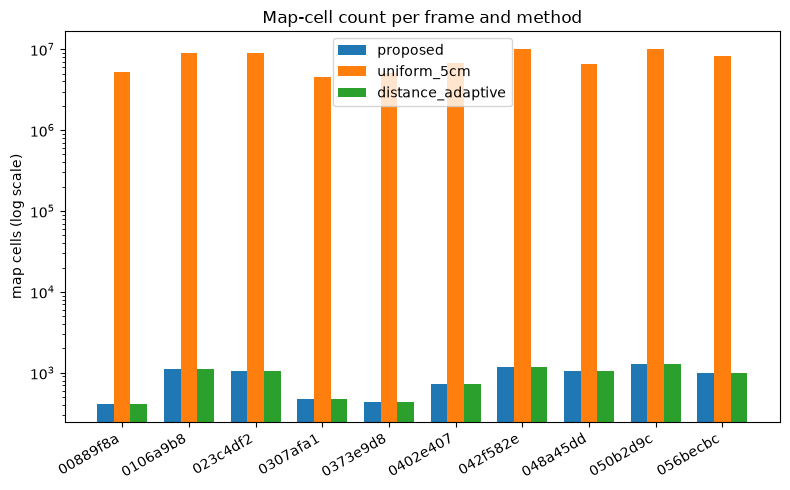

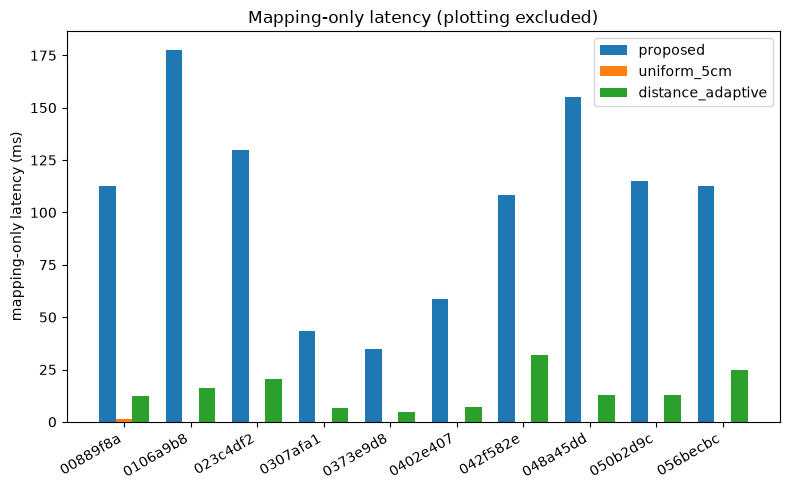

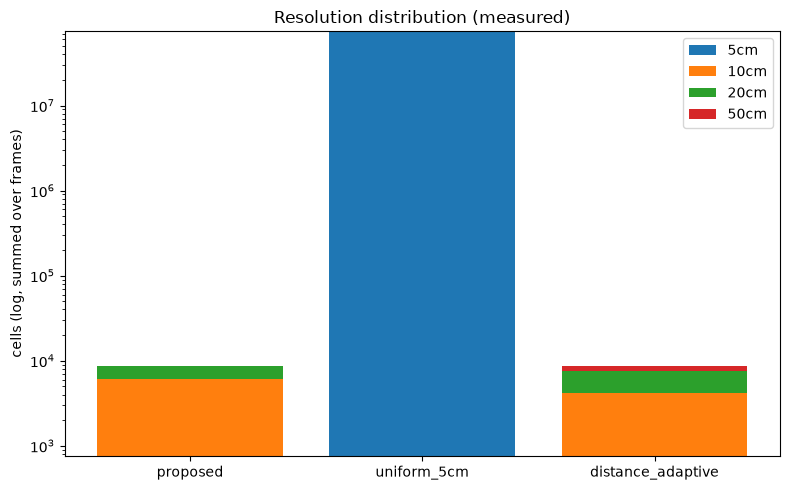

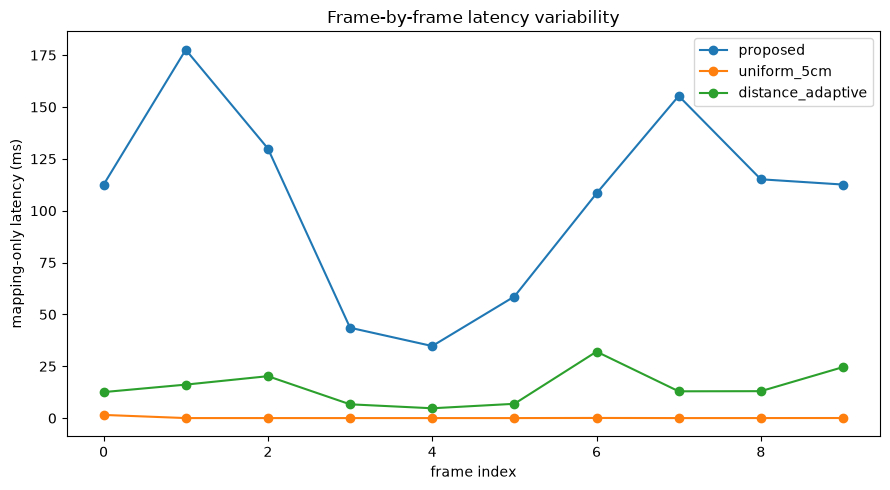

In [21]:
methods = ["proposed","uniform_5cm","distance_adaptive"]
x = np.arange(len(benchmark_df["frame_id"].unique())); w = 0.25; ok = benchmark_df[benchmark_df["status"]=="pass"]
fig, ax = plt.subplots(figsize=(8,5))
for k, m in enumerate(methods):
    ax.bar(x+(k-1)*w, ok[ok["method"]==m].sort_values("frame_id")["map_cells"], w, label=m)
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels([s[:8] for s in ok["frame_id"].unique()], rotation=30, ha="right")
ax.set_ylabel("map cells (log scale)"); ax.set_title("Map-cell count per frame and method"); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(FIGURES_ROOT,"cell_count_comparison.png"), dpi=150); plt.show()
fig, ax = plt.subplots(figsize=(8,5))
for k, m in enumerate(methods):
    ax.bar(x+(k-1)*w, ok[ok["method"]==m].sort_values("frame_id")["mapping_latency_ms"], w, label=m)
ax.set_xticks(x); ax.set_xticklabels([s[:8] for s in ok["frame_id"].unique()], rotation=30, ha="right")
ax.set_ylabel("mapping-only latency (ms)"); ax.set_title("Mapping-only latency (plotting excluded)"); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(FIGURES_ROOT,"latency_comparison.png"), dpi=150); plt.show()
fig, ax = plt.subplots(figsize=(8,5)); labels=["5cm","10cm","20cm","50cm"]; bottom=np.zeros(len(methods))
for j, col in enumerate(["res_5cm","res_10cm","res_20cm","res_50cm"]):
    vals=[resdist_df[resdist_df["method"]==m][col].sum() for m in methods]
    ax.bar(methods, vals, bottom=bottom, label=labels[j]); bottom=bottom+np.array(vals)
ax.set_yscale("log"); ax.set_ylabel("cells (log, summed over frames)"); ax.set_title("Resolution distribution (measured)"); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(FIGURES_ROOT,"resolution_distribution.png"), dpi=150); plt.show()
fig, ax = plt.subplots(figsize=(9,5))
for m in methods:
    sub=ok[ok["method"]==m].sort_values("frame_id"); ax.plot(range(len(sub)), sub["mapping_latency_ms"], marker="o", label=m)
ax.set_xlabel("frame index"); ax.set_ylabel("mapping-only latency (ms)"); ax.set_title("Frame-by-frame latency variability"); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(FIGURES_ROOT,"frame_latency.png"), dpi=150); plt.show()

## 22. Same-frame visual comparison (identical limits, aspect, figure size)

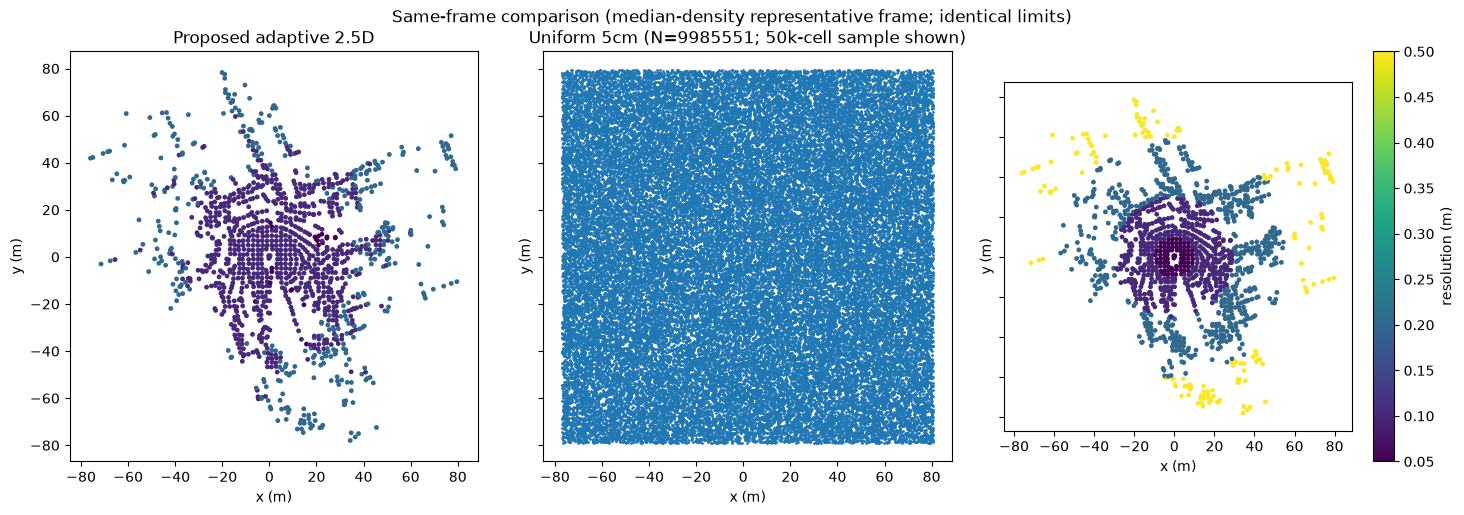

Representative frame: 050b2d9c4bb647b7ab4ee94bdb538e1d_LIDAR_TOP_xyzi.npy


In [22]:
uni_rep = build_uniform_map(rep["evaluation_area"], region_features=rep["region_features"],
    resolution_m=UNIFORM_RESOLUTION, return_arrays=True)
fig, axes = plt.subplots(1,3, figsize=(15,5), sharex=True, sharey=True)
axes[0].scatter(rep_prop["x"], rep_prop["y"], c=rep_prop["resolution"], s=6, vmin=0.05, vmax=0.50)
axes[0].set_title("Proposed adaptive 2.5D")
rng = np.random.default_rng(0); mask = rng.random(uni_rep.grid_x.size) < 50000/uni_rep.grid_x.size
axes[1].scatter(uni_rep.grid_x.ravel()[mask], uni_rep.grid_y.ravel()[mask], s=1, c="tab:blue")
axes[1].set_title(f"Uniform 5cm (N={uni_rep.exact_cells}; 50k-cell sample shown)")
sc = axes[2].scatter(rep_dist["x"], rep_dist["y"], c=rep_dist["resolution"], s=6, vmin=0.05, vmax=0.50)
for a in axes:
    a.set_aspect("equal", adjustable="box"); a.set_xlabel("x (m)"); a.set_ylabel("y (m)")
fig.colorbar(sc, ax=axes[2], label="resolution (m)")
fig.suptitle("Same-frame comparison (median-density representative frame; identical limits)")
fig.tight_layout(); fig.savefig(os.path.join(FIGURES_ROOT,"representative_frame_comparison.png"), dpi=150); plt.show()
print("Representative frame:", rep_file)

## 23. Saved benchmark outputs

In [23]:
import glob
for p in sorted(glob.glob(os.path.join(BENCHMARK_ROOT,"*"))) + sorted(glob.glob(os.path.join(FIGURES_ROOT,"*"))):
    print(("FIG  " if FIGURES_ROOT in p else "FILE ") + os.path.relpath(p, PROJECT_ROOT))

FILE results\benchmark\benchmark_config.json
FILE results\benchmark\benchmark_results.csv
FILE results\benchmark\benchmark_summary.csv
FILE results\benchmark\failure_log.csv
FIG  results\benchmark\figures
FILE results\benchmark\label_consistency.csv
FILE results\benchmark\reliability_results.csv
FILE results\benchmark\resolution_distribution.csv
FILE results\benchmark\same_distance_semantic_test.csv
FILE results\benchmark\scene_categories.csv
FILE results\benchmark\semantic_preservation.csv
FIG  results\benchmark\figures\cell_count_comparison.png
FIG  results\benchmark\figures\frame_latency.png
FIG  results\benchmark\figures\latency_comparison.png
FIG  results\benchmark\figures\representative_frame_comparison.png
FIG  results\benchmark\figures\resolution_distribution.png


## 24. Final validation (validity checklist + automated assertions)

In [24]:
# Validity: same frames ✓, same coverage (asserted §14) ✓, same coordinates/preprocessing/ROI ✓,
# frozen config ✓, no per-frame tuning ✓, no hand-entered values ✓, no silent discards (10/10 pass) ✓.
# Interpretation: INITIAL prototype benchmark on a 10-frame subset — no universality/production/safety claims.
for r in all_results:
    assert r["map_cells"] >= 0 and r["coverage_area"] > 0 and r["mapping_latency_ms"] >= 0
assert ((rep_prop["importance"] >= 0.0) & (rep_prop["importance"] <= 1.0)).all()
assert (rep_prop["resolution"] > 0).all() and (rep_dist["resolution"] > 0).all()
assert not benchmark_df[["map_cells","coverage_area","mapping_latency_ms","end_to_end_latency_ms"]].isna().any().any()
print("ALL FINAL ASSERTIONS PASSED — 13 September benchmark complete.")

ALL FINAL ASSERTIONS PASSED — 13 September benchmark complete.
